In [107]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [108]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPHOCS = 50

In [143]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle = True,
    image_size = (IMAGE_SIZE ,IMAGE_SIZE),
    batch_size = BATCH_SIZE

)

Found 4513 files belonging to 5 classes.


In [110]:
class_names =dataset.class_names
class_names

['Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'not_a_potato_leaf',
 'not_potato']

In [111]:
len(dataset)

142

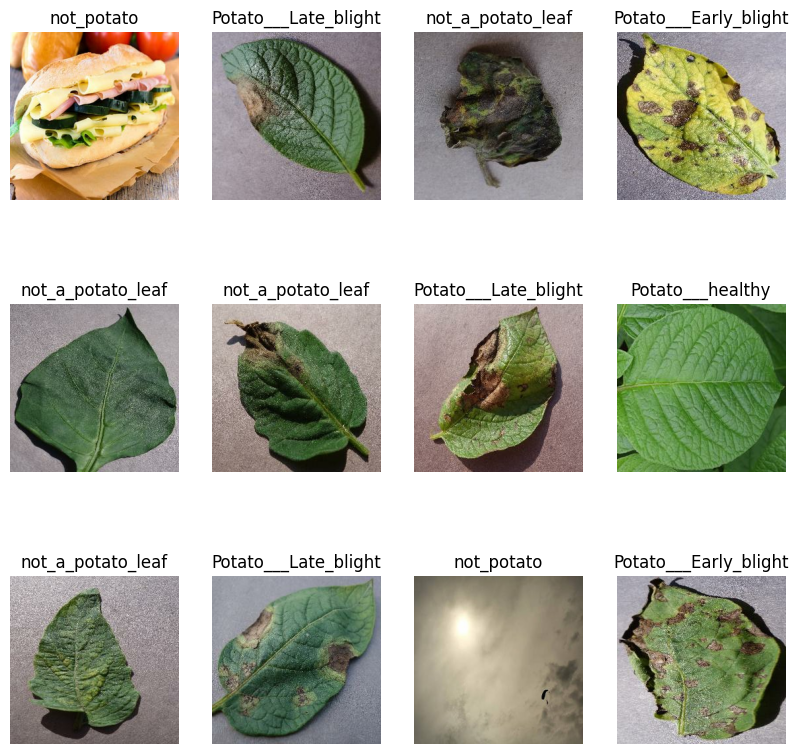

In [112]:
plt.figure(figsize=(10,10))
for image_batch, lable_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[lable_batch[i]])
        plt.axis("off")

In [113]:
train_size = 0.8
len(dataset)*train_size


113.60000000000001

In [114]:
import os, random

folder = "PlantVillage/not_a_potato_leaf"

images = os.listdir(folder)

# pick random 1000
keep = random.sample(images, 1000)

# delete rest
for img in images:
    if img not in keep:
        os.remove(os.path.join(folder, img))

print("Final count:", len(os.listdir(folder)))

Final count: 1000


In [115]:
import os

folder = "PlantVillage/not_potato"

print("Exists:", os.path.exists(folder))
print("Count:", len(os.listdir(folder)))
print(os.listdir(folder)[:20])

Exists: True
Count: 1000
['63.jpg', '189.jpg', '4203.jpg', '837.jpg', '3222.jpg', '5121.jpg', '2841.jpg', '4773.jpg', '1179.jpg', '4767.jpg', '2316.jpg', '5451.jpg', '1623.jpg', '4983.jpg', '5445.jpg', '3975.jpg', '4149.jpg', '2538.jpg', '2289.jpg', '5280.jpg']


In [116]:
import os, random

folder = "PlantVillage/not_potato"

images = os.listdir(folder)
keep = random.sample(images, 1000)

for img in images:
    if img not in keep:
        os.remove(os.path.join(folder, img))

print("Final count:", len(os.listdir(folder)))

Final count: 1000


In [117]:
import os

dataset_path = "PlantVillage"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)))

Potato___Early_blight : 1000
Potato___Late_blight : 1000
not_a_potato_leaf : 1000
not_potato : 1000
Potato___healthy : 515


In [118]:
train_ds = dataset.take(54)
len(train_ds)

54

In [119]:
test_ds=dataset.skip(54)
val_ds = test_ds.take(6)
test_ds = test_ds.skip(6)
len(test_ds)

82

In [120]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split = 0.1, test_split = 0.1, shuffle = True, shuffle_size = 10000):

    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)   
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds



In [121]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [122]:
len(train_ds), len(val_ds), len(test_ds)    

(113, 14, 15)

In [123]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [124]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])

In [125]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [126]:
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])
model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
model.summary()

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,021 (1.06 MB)

 Trainable params: 278,021 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [128]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPHOCS,
    batch_size = BATCH_SIZE,
    verbose = 1,

)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 50s 423ms/step - accuracy: 0.5669 - loss: 1.0258 - val_accuracy: 0.5134 - val_loss: 1.3053
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 48s 423ms/step - accuracy: 0.7506 - loss: 0.6564 - val_accuracy: 0.7723 - val_loss: 0.6092
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 48s 428ms/step - accuracy: 0.8205 - loss: 0.4581 - val_accuracy: 0.8571 - val_loss: 0.3611
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 54s 478ms/step - accuracy: 0.8700 - loss: 0.3469 - val_accuracy: 0.8326 - val_loss: 0.4187
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 56s 497ms/step - accuracy: 0.8919 - loss: 0.2928 - val_accuracy: 0.8906 - val_loss: 0.2739
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 56s 496ms/step - accuracy: 0.8946 - loss: 0.2666 - val_accuracy: 0.8951 - val_loss: 0.2957
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 56s 498ms/step - accuracy: 0.9234 - loss: 0.2101 - val_accuracy: 0.9152 - val_loss: 0.2152
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 56s 498ms/step - accuracy: 0.9270 - loss: 0

In [129]:
scores = model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.9771 - loss: 0.0596


In [130]:
scores

[0.05962694436311722, 0.9770833253860474]

In [131]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'training and validation accuracy')

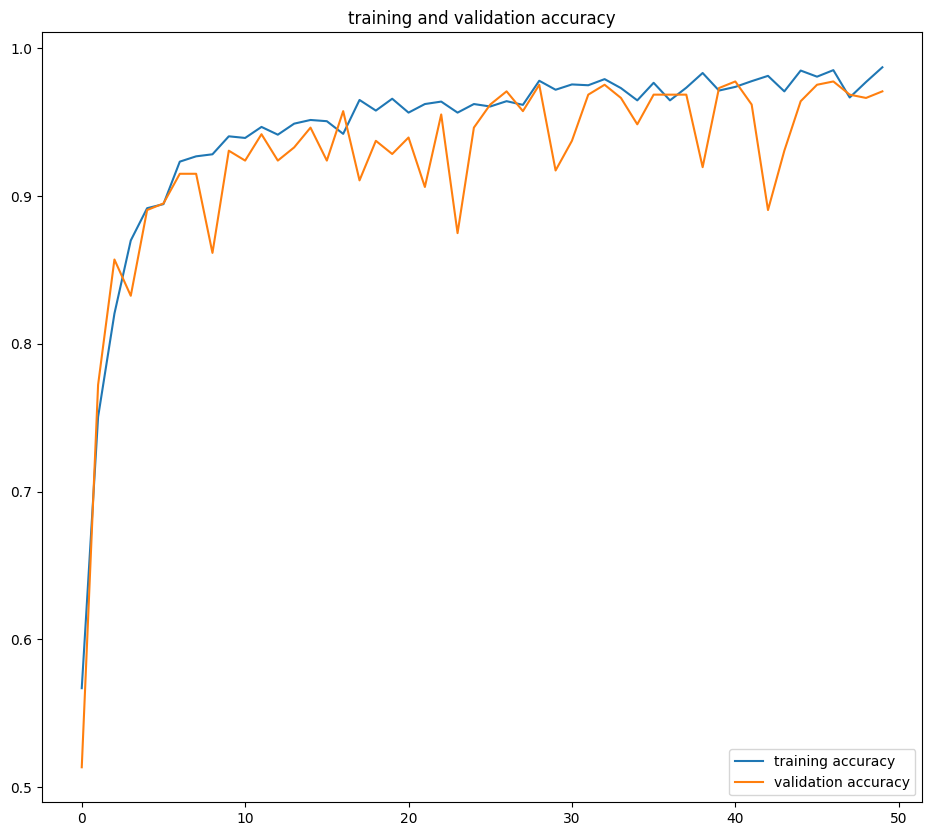

In [132]:
plt.figure(figsize=(25,10))
plt.subplot(1,2,1)
plt.plot(range(EPHOCS),acc,label = 'training accuracy')
plt.plot(range(EPHOCS),val_acc,label = 'validation accuracy')
plt.legend(loc='lower right')
plt.title('training and validation accuracy')

first image to predict
actual label: not_a_potato_leaf
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
predicted label: not_a_potato_leaf


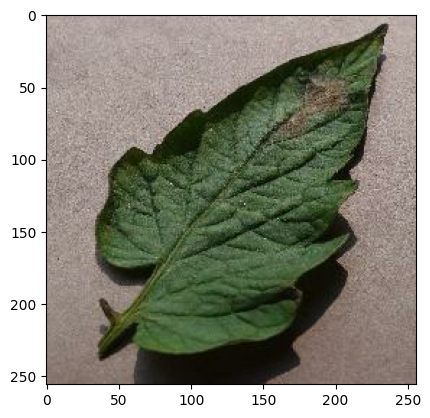

In [133]:
for images_batch,labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:", class_names[first_label])
    batch_prediction = model.predict(images_batch)
    print("predicted label:", class_names[np.argmax(batch_prediction[0])])


In [134]:
def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(img.numpy())
    img_array = tf.expand_dims(img_array,0)
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction[0])]
    confidence = round(100 * (np.max(prediction[0])),2)
    return predicted_class,confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


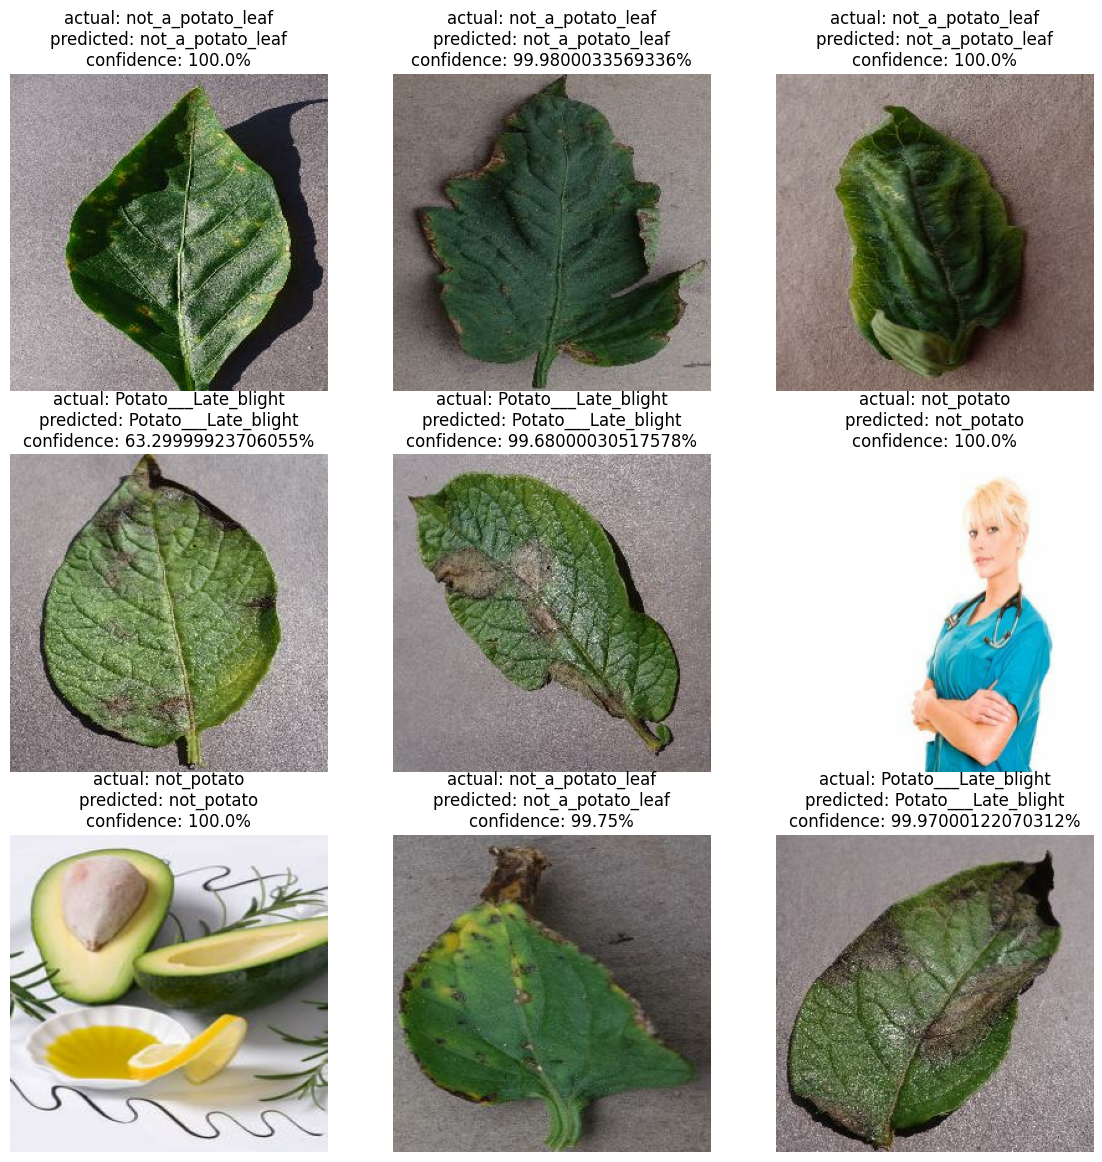

In [135]:
plt.figure(figsize=(14,14))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model,images[i])
        actual_class = class_names[labels[i]]
        plt.title(f"actual: {actual_class}\npredicted: {predicted_class}\nconfidence: {confidence}%")
        plt.axis("off")

In [136]:
import os

model_version = max([int(i.split(".")[0]) for i in os.listdir("./models")] + [0]) + 1

model.save(f"./models/{model_version}.keras")

In [137]:
model.save("potato_model.keras")

In [140]:
print(dataset.class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'not_a_potato_leaf', 'not_potato']
